In [11]:
import pandas as pd
import numpy as np
from datetime import datetime

In [3]:
# loading dataset

df = pd.read_csv(r"C:\Users\User\Desktop\week 1&2\1_E-Commerce_Dataset_Cleaning&_EDA\OnlineRetail.csv", encoding = "latin")

In [4]:
# copy dataset for cleaning

df1 = df.copy()

In [12]:
# data type check for dataset
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [14]:
# fixing data type for dataset
# changing InvoiceDate data type from str to datetime
df1["InvoiceDate"] = pd.to_datetime(df1["InvoiceDate"])

# Changing CustomerID datatype from float64 to str
df1["CustomerID"] = df1["CustomerID"].astype("str")

In [16]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  str           
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 62.3 MB


In [17]:
# identifying columns with missing values

df1.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
# % of missing values in each columns

round(((df1.isna().sum())/df1.count())*100,2)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     33.20
Country         0.00
dtype: float64

In [29]:
# handling missing values

# Description column has only 0.27% missing values. Since this represents a very small proportion of the dataset,
# rows with missing descriptions will be removed.
df1 = df1.dropna(subset =["Description"])

#CustomerID column has 33.20% missing values. Since removing this will lead to lossing large portion of the dateset
#rows with missing customerid will be replace with missing.
df1["CustomerID"] =  df1["CustomerID"].fillna("missing")

In [30]:
df1.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [33]:
# Duplicate records
df1.duplicated().sum()

np.int64(5268)

In [38]:
# Removing Duplicate records
df1 = df1.drop_duplicates()

In [39]:
df1.duplicated().sum()

np.int64(0)

In [44]:
df1.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [48]:
# text standardization and formatting
text_cols = ["Country", "Description"]

for col in text_cols:
    df1[col] = df1[col].str.strip().str.replace(r"\s+", " ", regex=True).str.title()

In [60]:
# invalid values
(df1["UnitPrice"]<0).sum()

np.int64(2)

In [61]:
df1[df1["UnitPrice"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust Bad Debt,1,2011-08-12 14:51:00,-11062.06,missing,United Kingdom
299984,A563187,B,Adjust Bad Debt,1,2011-08-12 14:52:00,-11062.06,missing,United Kingdom


In [63]:
df1[df1["Description"] == "Adjust Bad Debt"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust Bad Debt,1,2011-08-12 14:50:00,11062.06,missing,United Kingdom
299983,A563186,B,Adjust Bad Debt,1,2011-08-12 14:51:00,-11062.06,missing,United Kingdom
299984,A563187,B,Adjust Bad Debt,1,2011-08-12 14:52:00,-11062.06,missing,United Kingdom


In [65]:
df1.loc[df1["Description"] == "Adjust Bad Debt", "UnitPrice"] = 11062

In [66]:
(df1["UnitPrice"]<0).sum()

np.int64(0)

In [99]:
(df1["UnitPrice"] == 0).sum()

np.int64(1056)

In [73]:
# Negative Quantity values account for only 1.8% of the dataset.
# These values likely represent returned or cancelled transactions, so they were retained
# to preserve the original transaction records.

((df1["Quantity"]<0).sum()/df1.count())*100

InvoiceNo      1.817122
StockCode      1.817122
Description    1.817122
Quantity       1.817122
InvoiceDate    1.817122
UnitPrice      1.817122
CustomerID     1.817122
Country        1.817122
dtype: float64

In [ ]:
# outlier identification 
df1[df1["Quantity"]==df1["Quantity"].max()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"Paper Craft , Little Birdie",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [89]:

df1[df1["Quantity"]==df1["Quantity"].min()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540422,C581484,23843,"Paper Craft , Little Birdie",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


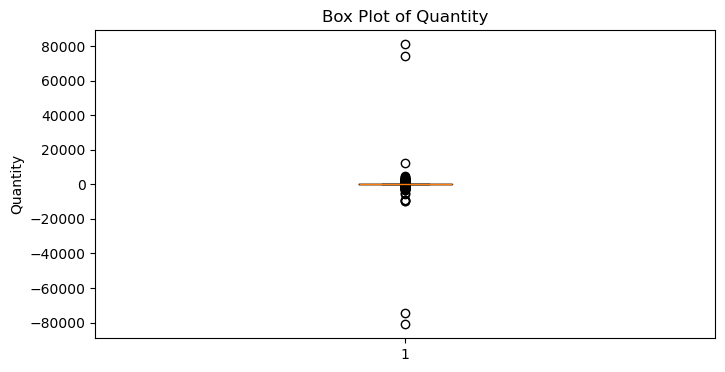

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(df1["Quantity"])
plt.title("Box Plot of Quantity")
plt.ylabel("Quantity")
plt.show()

In [85]:
df1[df1["Quantity"] > df1["Quantity"].quantile(0.999995)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,Medium Ceramic Top Storage Jar,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
502122,578841,84826,Asstd Design 3D Paper Stickers,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
540421,581483,23843,"Paper Craft , Little Birdie",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [88]:
df1[df1["Quantity"] < df1["Quantity"].quantile(0.00001)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4287,C536757,84347,Rotating Silver Angels T-Light Hldr,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom
61624,C541433,23166,Medium Ceramic Top Storage Jar,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
225528,556687,23003,Printing Smudges/Thrown Away,-9058,2011-06-14 10:36:00,0.00,missing,United Kingdom
225529,556690,23005,Printing Smudges/Thrown Away,-9600,2011-06-14 10:37:00,0.00,missing,United Kingdom
225530,556691,23005,Printing Smudges/Thrown Away,-9600,2011-06-14 10:37:00,0.00,missing,United Kingdom
540422,C581484,23843,"Paper Craft , Little Birdie",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


In [76]:
df1.to_csv("OnlineRetail_Cleaned.csv" , index = False)

### Cleaning Summary

|Issues Found| Action Taken|
|-------------|------------|
|Data type issue in 2 columns; CustomerID which was stored as float64 instead of string and InvoiceDate which was stored as str instead of Datetime| used `pd.to_datetime` fuction for InvoiceDate to convert it to datetime datatype and CustomerID used `astype` to change to str|
|Found missing values in 2 columns; `Description` Column and `CustomerID` | Droped the missing values in `Description` column because it was only **0.27%** missing values.For CustomerID it had **33.2%** missing values.Since droping it was going to lead to loss of large % of the dataset i decided to fillna it with `missing`|
|2 negative values in  `UnitPrice` Column| identified the values were on the negative side instead of positive so i just replaced it with actual price|
|1.8% negative values in the `quantity` Column| left it like that because only few values had negative|
| Zero values were identified in the `UnitPrice` column (1000 records). | The values were retained because they represent a very small proportion of the dataset and may correspond to special transactions such as free items, promotions, or adjustments. They will not affect revenue calculations since their value is zero. |
| Outliers were identified in the `Quantity` column using a box plot, including extremely high and negative values. | The outliers were investigated and retained because they represented valid transactions such as bulk purchases and returned/cancelled items rather than data entry errors. |